In [16]:
import os

import pandas as pd

from framework.dataset_specification import NamedDatasetSpecifications, DatasetSpecification
from framework.enumerations import EvaluationDatasetSampling
from framework.flow_transformer_multi_classification import FlowTransformer
from framework.flow_transformer_parameters import FlowTransformerParameters
from implementations.classification_heads import *
from implementations.input_encodings import *
from implementations.pre_processings import StandardPreProcessing
from implementations.transformers.basic_transformers import BasicTransformer
from implementations.transformers.named_transformers import *

In [17]:
encodings = [
    NoInputEncoder(),
    RecordLevelEmbed(64),
    CategoricalFeatureEmbed(EmbedLayerType.Dense, 16),
    CategoricalFeatureEmbed(EmbedLayerType.Lookup, 16),
    CategoricalFeatureEmbed(EmbedLayerType.Projection, 16),
    RecordLevelEmbed(64, project=True)
]

classification_heads = [
    LastTokenClassificationHead(),
    FlattenClassificationHead(),
    GlobalAveragePoolingClassificationHead(),
    CLSTokenClassificationHead(),
    FeaturewiseEmbedding(project=False),
    FeaturewiseEmbedding(project=True),
]

transformers = [
    BasicTransformer(2, 128, n_heads=2),
    BasicTransformer(2, 128, n_heads=2, is_decoder=True),
    GPTSmallTransformer(),
    BERTSmallTransformer()
]

In [18]:
custom_dataset_spec = DatasetSpecification(
    include_fields=['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'FLOW_DURATION_MILLISECONDS', 'OUT_PKTS', 'OUT_BYTES', 'IN_PKTS', 'IN_BYTES', 'L7_PROTO', 'TCP_FLAGS'],
    categorical_fields=['L4_SRC_PORT', 'L4_DST_PORT', 'PROTOCOL', 'L7_PROTO', 'TCP_FLAGS'],
    class_column="Attack",
    benign_label="Benign"
)

datasets = [
    ("Balanced_Dataset_Multi", "../FlowTransformer/data/balanced_dataset_tcp_udp.csv", custom_dataset_spec, 0.2, EvaluationDatasetSampling.RandomRows)
]

In [19]:
pre_processing = StandardPreProcessing(n_categorical_levels=32)

# Define the transformer
ft = FlowTransformer(pre_processing=pre_processing,
                     input_encoding=encodings[0],
                     sequential_model=transformers[0],
                     classification_head=classification_heads[0],
                     params=FlowTransformerParameters(window_size=8, mlp_layer_sizes=[128], mlp_dropout=0.1))

# Load the specific dataset
dataset_name, dataset_path, dataset_specification, eval_percent, eval_method = datasets[0]
ft.load_dataset(dataset_name, dataset_path, dataset_specification, evaluation_dataset_sampling=eval_method, evaluation_percent=eval_percent)


Attempting to read dataset from path ../FlowTransformer/data/balanced_dataset_tcp_udp.csv...
Set y to = Attack
Class map: {0: 'Benign', 1: 'tcp', 2: 'udp'}
Class num: 3
Converting numerical columns to floats, and removing out of range values...
Applying pre-processing to numerical values
[Numerical 1 / 5] Processing numerical column FLOW_DURATION_MILLISECONDS...
[Numerical 2 / 5] Processing numerical column OUT_PKTS...
[Numerical 3 / 5] Processing numerical column OUT_BYTES...
[Numerical 4 / 5] Processing numerical column IN_PKTS...
[Numerical 5 / 5] Processing numerical column IN_BYTES...
Applying pre-processing to categorical values
[Categorical 1 / 5] Processing categorical column L4_SRC_PORT...
Encoding the 32 levels for L4_SRC_PORT
[Categorical 2 / 5] Processing categorical column L4_DST_PORT...
Encoding the 32 levels for L4_DST_PORT
[Categorical 3 / 5] Processing categorical column PROTOCOL...
Encoding the 5 levels for PROTOCOL
[Categorical 4 / 5] Processing categorical column L7

/home/kali/workplace/myids/FlowTransformer_MultiClassification_Extension/framework/flow_transformer_multi_classification.py:190: UserWarning: Using EvaluationDatasetSampling options other than LastRows might leak some information during training, if for example the context window leading up to a particular flow contains an evaluation flow, and this flow has out of range values (out of range to when pre-processing was applied on the training flows), then the model might potentially learn to handle these. In any case, no class leakage is present.
  warnings.warn("Using EvaluationDatasetSampling options other than LastRows might leak some information during training, if for example the context window leading up to a particular flow contains an evaluation flow, and this flow has out of range values (out of range to when pre-processing was applied on the training flows), then the model might potentially learn to handle these. In any case, no class leakage is present.")


,FLOW_DURATION_MILLISECONDS,OUT_PKTS,OUT_BYTES,IN_PKTS,IN_BYTES,L4_SRC_PORT_1,L4_SRC_PORT_2,L4_SRC_PORT_3,L4_SRC_PORT_4,L4_SRC_PORT_5,...,TCP_FLAGS_8,TCP_FLAGS_9,TCP_FLAGS_10,TCP_FLAGS_11,TCP_FLAGS_12,TCP_FLAGS_13,TCP_FLAGS_14,TCP_FLAGS_15,TCP_FLAGS_16,TCP_FLAGS_17
0,0.710869,0.219600,0.561348,0.173847,0.371261,True,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,0.000000,0.000000,0.122540,0.000000,0.000000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0.000000,0.000000,0.122540,0.000000,0.000000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0.000000,0.000000,0.122540,0.000000,0.000000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.000000,0.059344,0.264783,0.091847,0.246059,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,0.000000,0.000000,0.304556,0.000000,0.000000,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19996,0.452565,0.137793,0.351373,0.134554,0.288161,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19997,0.000000,0.000000,0.122540,0.000000,0.000000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
19998,0.000000,0.000000,0.122540,0.000000,0.000000,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
m = ft.build_model()
m.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_FLOW_DURATION_MILLISECON  [(None, 8, 1)]      0           []                               
 DS (InputLayer)                                                                                  
                                                                                                  
 input_OUT_PKTS (InputLayer)    [(None, 8, 1)]       0           []                               
                                                                                                  
 input_OUT_BYTES (InputLayer)   [(None, 8, 1)]       0           []                               
                                                                                                  
 input_IN_PKTS (InputLayer)     [(None, 8, 1)]       0           []                         

Classes in eval set:
	Benign
	tcp
	udp
Building eval dataset...
Splitting dataset to featurewise...
Evaluation dataset is built!
Computing and print the number of each class in the evaluation set...
Attack class Benign samples in eval set: 1972
Attack class tcp samples in eval set: 1022
Attack class udp samples in eval set: 1005
Epoch = 0 / 5 (early stop in 5), step = 61, loss = 0.49203, results = [0.49202820658683777, 0.75] -- elapsed (train): 1.18s
Epoch = 2 / 5 (early stop in 4), step = 30, loss = 0.49583, results = [0.4958250820636749, 0.59375] -- elapsed (train): 3.24s
Epoch = 4 / 5 (early stop in 4), step = 8, loss = 0.46714, results = [0.4671444296836853, 0.6640625] -- elapsed (train): 5.26s
125/125 [==============================] - 1s 2ms/step

Raw report :
{'0': {'precision': 0.9984599589322382, 'recall': 0.9863083164300203, 'f1-score': 0.9923469387755102, 'support': 1972.0}, '1': {'precision': 0.4961612284069098, 'recall': 0.5058708414872799, 'f1-score': 0.500968992248062, '

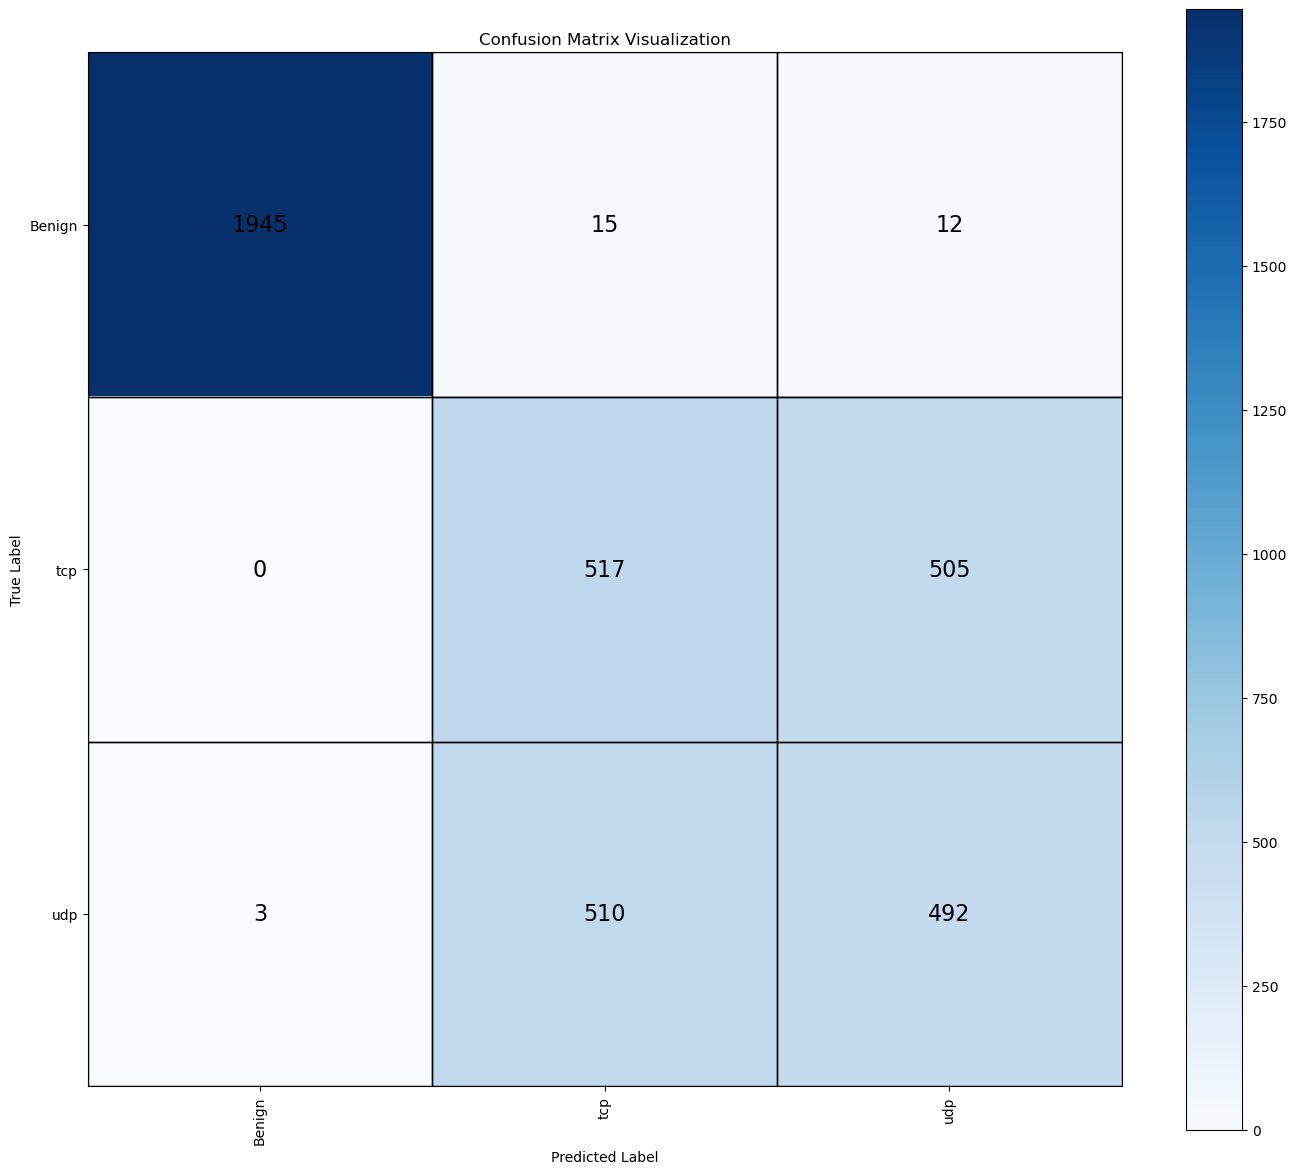

In [21]:
import tensorflow as tf



# 关闭 jit_compile 以避免某些环境下图导出不稳定；并启用梯度裁剪减少训练发散风险

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0)

m.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'], jit_compile=False)



# Get the evaluation results

eval_results: pd.DataFrame

(train_results, eval_results, final_epoch) = ft.evaluate(m, batch_size=128, epochs=5, steps_per_epoch=64, early_stopping_patience=5)



# print(eval_results)


In [ ]:
# 仅导出 ONNX + 元信息（RKNN 转换放到独立脚本 tools/onnx_to_rknn.py 在另一台机器执行）

print("\n--> 1. 正在将 Keras 模型导出为 ONNX 格式...")



import os

import json

import numpy as np

import tf2onnx

import tensorflow as tf



onnx_save_path = os.path.join("..", "models", "t_multi_class.onnx")

rknn_save_path = os.path.join("..", "models", "transformer_multi_class_model.rknn")

meta_save_path = os.path.splitext(onnx_save_path)[0] + ".meta.json"



# 导出模型输入元信息，供后续 RKNN 推理/主程序读取

model_input_names = []

model_expected_dims = {}

for tensor in m.inputs:

    name = tensor.name.split(':')[0] if ':' in tensor.name else tensor.name

    model_input_names.append(name)

    shape = tensor.shape.as_list() if hasattr(tensor.shape, "as_list") else list(tensor.shape)

    if len(shape) == 3 and shape[-1] is not None and int(shape[-1]) != 1:

        feat_name = name.replace("input_", "", 1)

        model_expected_dims[feat_name] = int(shape[-1])



# 导出类别元信息（用于推理时把 0/1/2 映射为真实标签）

class_map_raw = getattr(ft, "class_map", None)
class_items = []
if isinstance(class_map_raw, dict):
    for k, v in class_map_raw.items():
        try:
            idx = int(k)
        except (TypeError, ValueError):
            continue
        class_items.append((idx, str(v)))
class_items.sort(key=lambda x: x[0])

class_map = {str(idx): label for idx, label in class_items}
class_labels = [label for _, label in class_items]

benign_label = None
if "dataset_specification" in locals() and hasattr(dataset_specification, "benign_label"):
    benign_label = str(dataset_specification.benign_label)
elif hasattr(ft, "dataset_specification") and hasattr(ft.dataset_specification, "benign_label"):
    benign_label = str(ft.dataset_specification.benign_label)

benign_class_index = None
if benign_label and class_labels:
    benign_key = benign_label.strip().lower()
    for idx, label in enumerate(class_labels):
        if label.strip().lower() == benign_key:
            benign_class_index = idx
            break

model_meta = {
    "model_input_names": model_input_names,
    "model_expected_dims": model_expected_dims,
    "model_output_name": m.outputs[0].name.split(':')[0] if m.outputs else None,
    "class_map": class_map,
    "class_labels": class_labels,
    "benign_label": benign_label,
    "benign_class_index": benign_class_index
}

with open(meta_save_path, "w", encoding="utf-8") as f:
    json.dump(model_meta, f, ensure_ascii=False, indent=2)

print(f"模型元信息已保存至 {meta_save_path}")
if class_labels:
    print(f"类别标签({len(class_labels)}): {class_labels}")
else:
    print("WARNING: 未检测到 class_map/class_labels，推理侧将回退为类别索引显示")



# 固定 batch 维度，避免导出动态维导致后续工具链不兼容

input_signature = []

for tensor in m.inputs:

    shape = list(tensor.shape)

    shape[0] = 1

    name = tensor.name.split(':')[0] if ':' in tensor.name else tensor.name

    input_signature.append(tf.TensorSpec(shape=tuple(shape), dtype=tensor.dtype, name=name))



model_proto, _ = tf2onnx.convert.from_keras(

    m,

    input_signature=input_signature,

    output_path=onnx_save_path,

    opset=13,

)

print(f"ONNX 模型已保存至 {onnx_save_path}")



# 导出后检查 ONNX 是否有 NaN/Inf 权重，避免后续 RKNN 出现恒定输出

print("\n--> 1.1 正在校验 ONNX 权重...")

import onnx

from onnx import numpy_helper



onnx_model = onnx.load(onnx_save_path)

bad_inits = []

for init in onnx_model.graph.initializer:

    arr = numpy_helper.to_array(init)

    if np.issubdtype(arr.dtype, np.floating):

        if np.isnan(arr).any() or np.isinf(arr).any():

            bad_inits.append(init.name)



if bad_inits:

    raise RuntimeError(

        "导出的 ONNX 含 NaN/Inf 权重，已停止。"

        f"\n异常参数数量: {len(bad_inits)}，示例: {bad_inits[:5]}"

    )



print("ONNX 权重校验通过")



print("\n--> 2. 本机到此结束（仅训练+导出 ONNX）")

print("请把以下文件拷贝到转换机：")

print(f"  - {onnx_save_path}")

print(f"  - {meta_save_path}")



print("\n在转换机执行：")

print(

    "python tools/onnx_to_rknn.py "

    f"--onnx {onnx_save_path} "

    f"--output {rknn_save_path} "

    "--target rk3588 --copy-meta"

)



--> 1. 正在将 Keras 模型导出为 ONNX 格式...
模型元信息已保存至 ../models/t_multi_class.meta.json
类别标签(3): ['Benign', 'tcp', 'udp']


2026-04-12 18:35:43.465612: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-04-12 18:35:43.465686: I tensorflow/core/grappler/clusters/single_machine.cc:358] Starting new session
2026-04-12 18:35:43.469081: I tensorflow/core/grappler/optimizers/meta_optimizer.cc:1164] Optimization results for grappler item: graph_to_optimize
  function_optimizer: function_optimizer did nothing. time = 0.004ms.
  function_optimizer: function_optimizer did nothing. time = 0ms.

2026-04-12 18:35:43.654940: I tensorflow/core/grappler/devices.cc:66] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
2026-04-12 18:35:43.655018: I tensorflow/core/grappler/clusters/single_machine.cc:358] Starting new session
2026-04-12 18:35:43.676122: I tensorflow/core/grappler/optimizers/meta_optimizer.cc:1164] Optimization results for grappler item: graph_to_optimize
  constant_folding: Graph size after: 285 nodes (-76), 348 edges (-

ONNX 模型已保存至 ../models/t_multi_class.onnx

--> 1.1 正在校验 ONNX 权重...
ONNX 权重校验通过

--> 2. 本机到此结束（仅训练+导出 ONNX）
请把以下文件拷贝到转换机：
  - ../models/t_multi_class.onnx
  - ../models/t_multi_class.meta.json

在转换机执行：
python tools/onnx_to_rknn.py --onnx ../models/t_multi_class.onnx --output ../models/transformer_multi_class_model.rknn --target rk3588 --copy-meta
